# 💎 Diamond Dynamics: Price Prediction and Market Segmentation

# Data Collection

In [19]:
import pandas as pd
file_path = r"C:\Users\ADMIN\Documents\mini_project_guvi\project_diamond\Data_set\diamonds.csv"
data = pd.read_csv(file_path)

# Data preview

In [20]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
data.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [21]:
data.shape

(53940, 10)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [23]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [24]:
data.describe(include=object)

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


# Data Preprocessing

# Handling Missing Values

In [25]:
data.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [26]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Length: 53940, dtype: bool

In [27]:
duplicates = data[data.duplicated()]
print(duplicates)

       carat    cut color clarity  depth  table  price     x     y     z
1005    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
1006    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
1007    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
1008    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
2025    1.52   Good     E      I1   57.3   58.0   3105  7.53  7.42  4.28
...      ...    ...   ...     ...    ...    ...    ...   ...   ...   ...
47969   0.52  Ideal     D     VS2   61.8   55.0   1919  5.19  5.16  3.20
49326   0.51  Ideal     F    VVS2   61.2   56.0   2093  5.17  5.19  3.17
49557   0.71   Good     F     SI2   64.1   60.0   2130  0.00  0.00  0.00
50079   0.51  Ideal     F    VVS2   61.2   56.0   2203  5.19  5.17  3.17
52861   0.50   Fair     E     VS2   79.0   73.0   2579  5.21  5.18  4.09

[146 rows x 10 columns]


In [28]:
data.drop_duplicates(keep = "first", inplace = True)

In [29]:
data.duplicated().sum()

np.int64(0)

# Handling Outliers

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
num_cols = ["carat", "depth", "table", "price", "x", "y", "z"]

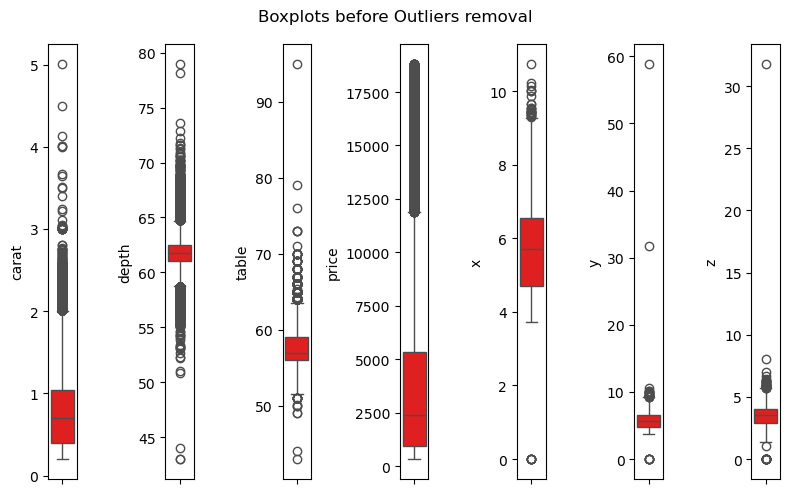

In [32]:
# Loop through numerical columns and create boxplots

plt.figure(figsize=(8, 5))
plt.suptitle("Boxplots before Outliers removal")
for i in range(0, len(num_cols)):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=data[num_cols[i]],color='red')
    plt.tight_layout()

# IQR Method

In [33]:
import numpy as np

for col in num_cols:

    Q1 = data[col].quantile(0.25)  # 25th percentile
    Q3 = data[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range

    # Define lower and upper bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values at lower and upper bound
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

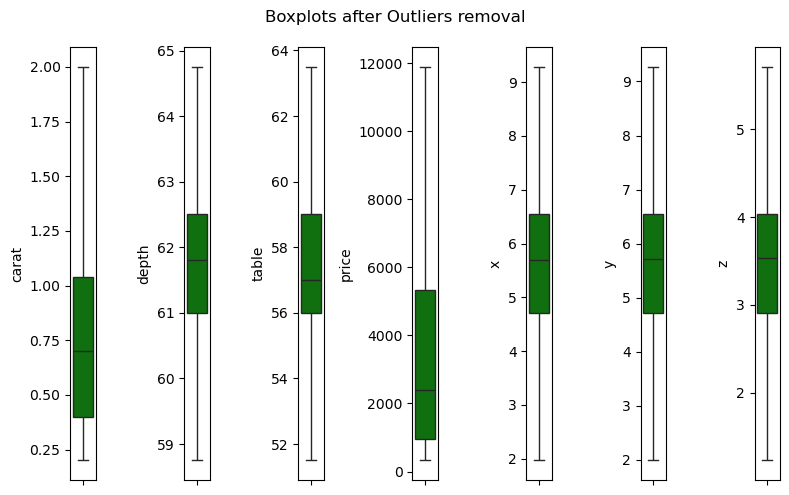

In [34]:
# Loop through numerical columns and create boxplots

plt.figure(figsize=(8, 5))
plt.suptitle("Boxplots after Outliers removal")
for i in range(0, len(num_cols)):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=data[num_cols[i]],color='green')
    plt.tight_layout()

In [35]:
data[num_cols].skew()

carat    0.899170
depth   -0.228563
table    0.472532
price    1.148606
x        0.388185
y        0.384552
z        0.372849
dtype: float64

In [37]:
columns = ["carat", "depth", "table", "price", "x", "y", "z"]
skewness = data[columns].skew()
skewness

carat    0.899170
depth   -0.228563
table    0.472532
price    1.148606
x        0.388185
y        0.384552
z        0.372849
dtype: float64

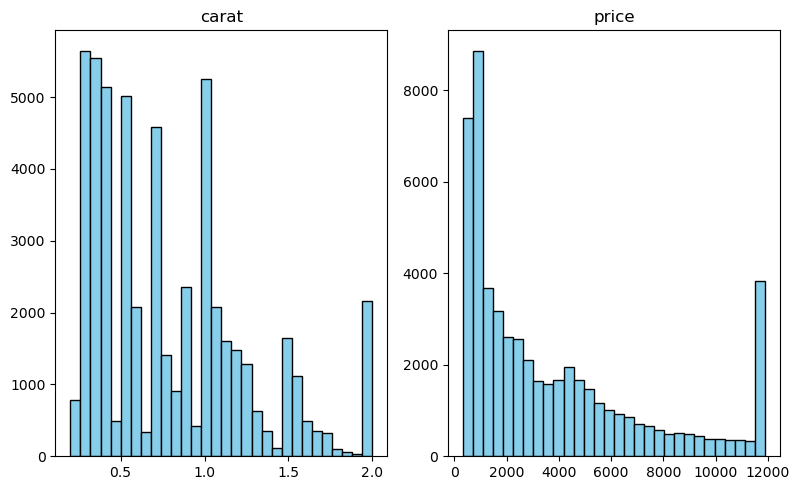

In [40]:
# Select numerical columns with high skewness (absolute skewness > 0.5)
skewed_cols = skewness[abs(skewness) > 0.5].index

# Plot histograms before transformation
plt.figure(figsize=(8, 5))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(1,2, i)  # Adjust grid size as needed
    plt.hist(data[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

In [41]:
import numpy as np

data["carat"] = np.log1p(data["carat"])
data["price"] = np.log1p(data["price"])


In [45]:
data[columns].skew()

carat    0.493974
depth   -0.228563
table    0.472532
price    0.030932
x        0.388185
y        0.384552
z        0.372849
dtype: float64

📌 Exploratory Data Analysis (EDA)

# Distribution plots for price, carat, x, y, z - Univariate Analysis

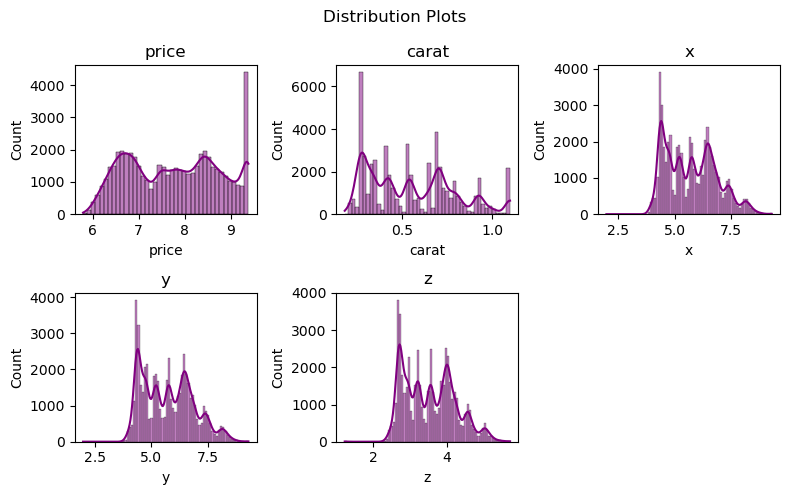

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['price','carat','x','y','z']

plt.figure(figsize=(8,5))
plt.suptitle("Distribution Plots")

for i, col in enumerate(cols):
    plt.subplot(2,3,i+1)
    sns.histplot(data[col], kde=True, color='purple')
    plt.title(col)

plt.tight_layout()
plt.show()


Price → Right-skewed distribution; higher values are less frequent. Log transformation is appropriate.

Carat → Moderately right-skewed; larger diamonds appear less often. Transformation can help.

X, Y, Z → Mostly near normal distribution with slight right skew; values cluster around the center.

# Count plots for categorical features (cut, color, clarity) - Univariate Analysis

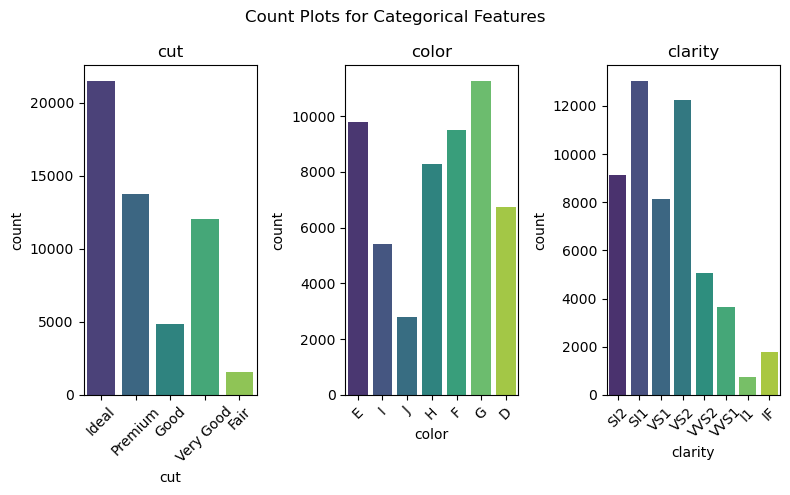

In [51]:
cat_cols = ['cut','color','clarity']

plt.figure(figsize=(8,5))
plt.suptitle("Count Plots for Categorical Features")

for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(x=data[col],hue=data[col], palette="viridis")
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Cut: Ideal cut diamonds are the most common, while Fair cut diamonds are the least common.
Color: Diamonds with G color appear most frequently, while J is the least common.
Clarity: SI1 and VS2 categories dominate the dataset, while I1 and IF occur rarely.

# Price variation with carat, cut, color, clarity using boxplots - Bivariate Analysis

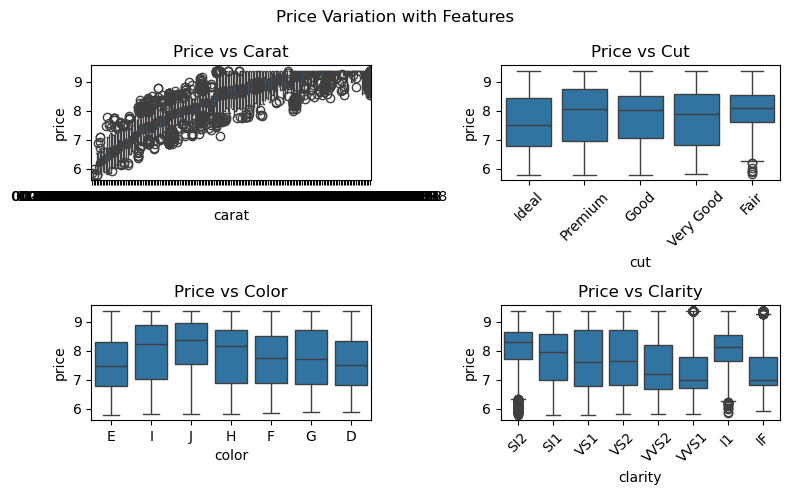

In [52]:
plt.figure(figsize=(8,5))
plt.suptitle("Price Variation with Features")

# Price vs Carat
plt.subplot(2,2,1)
sns.boxplot(x=data['carat'], y=data['price'])
plt.title("Price vs Carat")

# Price vs Cut
plt.subplot(2,2,2)
sns.boxplot(x=data['cut'], y=data['price'])
plt.xticks(rotation=45)
plt.title("Price vs Cut")

# Price vs Color
plt.subplot(2,2,3)
sns.boxplot(x=data['color'], y=data['price'])
plt.title("Price vs Color")

# Price vs Clarity
plt.subplot(2,2,4)
sns.boxplot(x=data['clarity'], y=data['price'])
plt.xticks(rotation=45)
plt.title("Price vs Clarity")

plt.tight_layout()
plt.show()


Carat is the strongest factor affecting diamond price, while cut, color, and clarity also influence price but with smaller variation.

# Correlation heatmap for numerical features - Multivariate Analysis

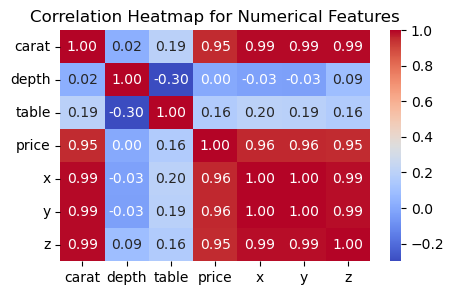

In [54]:
# select numerical columns
num_cols = ['carat','depth','table','price','x','y','z']

# compute correlation
corr = data[num_cols].corr()

plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap for Numerical Features")
plt.show()

Carat vs Price: Very strong positive correlation (0.95) → larger diamonds cost more.
X, Y, Z vs Price: Strong positive correlation (~0.95–0.96) → diamond dimensions strongly influence price.
Carat vs X, Y, Z: Extremely high correlation (~0.99) → carat represents diamond size, so dimensions increase with carat.
Depth & Table: Very weak correlation with price → these features have less influence on price.
Final - Carat and diamond dimensions (x, y, z) are the most important predictors of price, while depth and table contribute less.

# Scatterplot matrix for carat, x, y, z, and price	Multivariate Analysis

# Scatterplot Matrix
--A scatterplot matrix (also called a pair plot) is a visualization that shows scatterplots between every pair of numerical variables in a dataset.

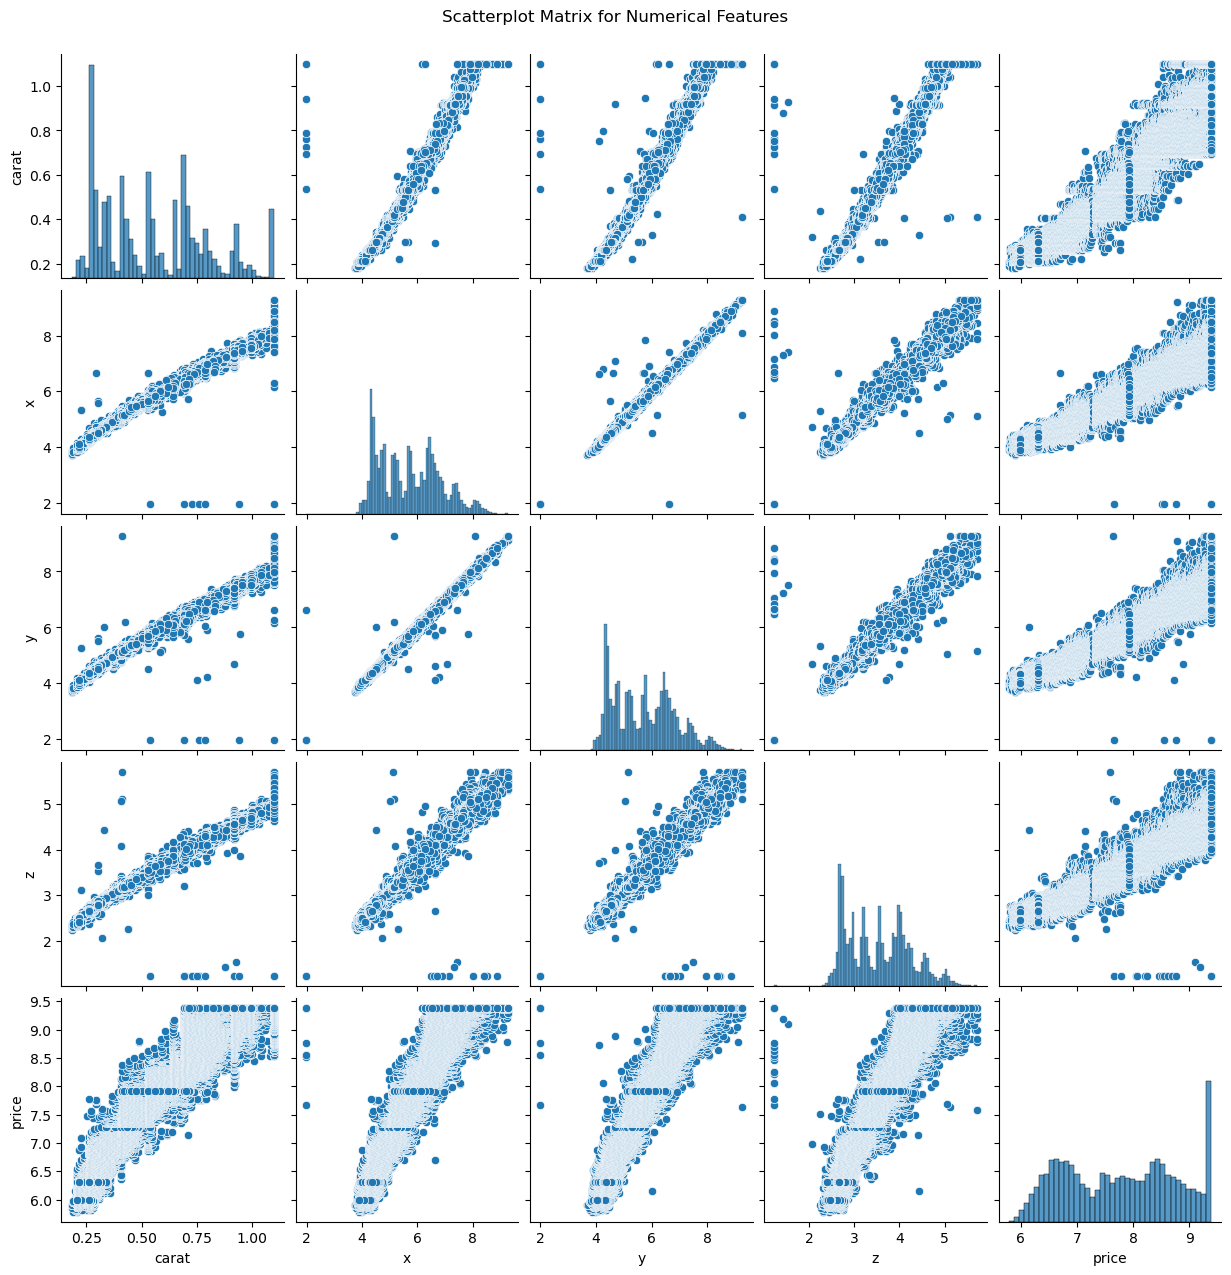

In [55]:
cols = ['carat','x','y','z','price']

sns.pairplot(data[cols])
plt.suptitle("Scatterplot Matrix for Numerical Features", y=1.02)

plt.show()

Carat vs Price: Strong positive relationship → as carat increases, price increases significantly.
X, Y, Z vs Price: Clear positive trend → larger diamond dimensions lead to higher prices.
Carat vs X, Y, Z: Very strong linear relationship → these variables represent diamond size, so they increase together.
X, Y, Z among themselves: Almost perfect correlation → the three dimensions grow proportionally.
Outliers: A few unusual points appear in x, y, z, indicating possible measurement errors or rare diamonds.
Final - Diamond size features (carat, x, y, z) are highly correlated with each other and are the strongest factors influencing price.

# Pairwise relationships using sns.pairplot() -	Multivariate Analysis

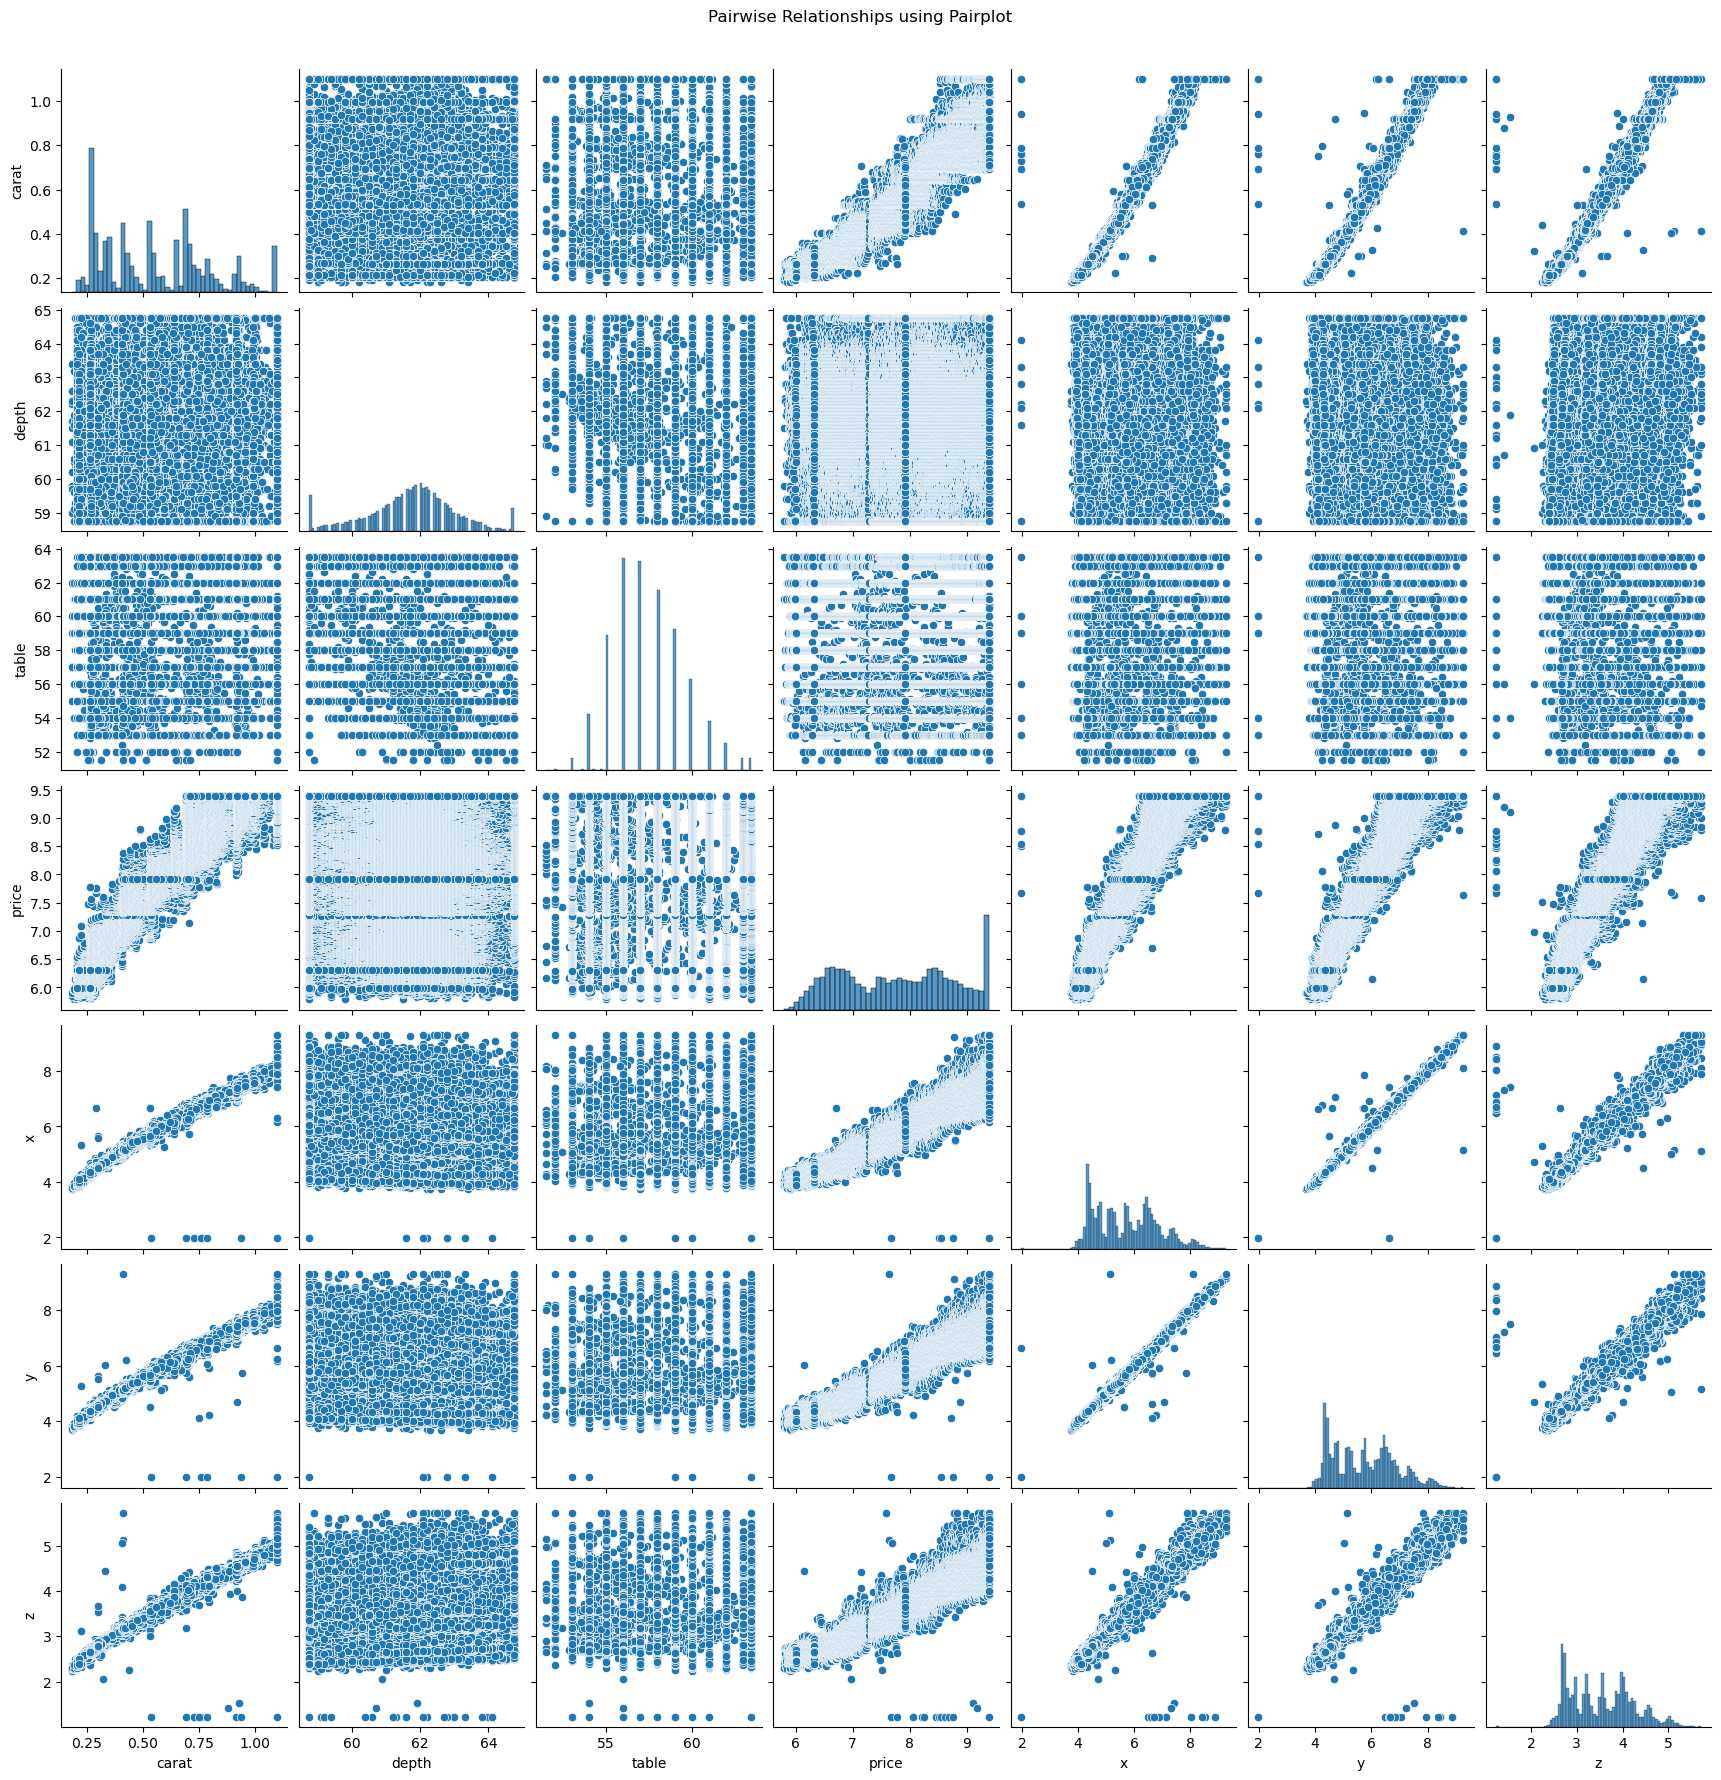

In [56]:
num_cols = ['carat','depth','table','price','x','y','z']

sns.pairplot(data[num_cols], diag_kind='hist')

plt.suptitle("Pairwise Relationships using Pairplot", y=1.02)
plt.show()


#Carat vs Price: Strong positive relationship → diamonds with higher carat weight have higher prices.
X, Y, Z vs Price: Diamond dimensions also show a strong positive relationship with price.
Carat vs X, Y, Z: Very strong linear relationship → these variables represent diamond size, so they increase together.
Depth & Table: Show weak relationships with price compared to other features.
Outliers: Some unusual values appear in x, y, z, indicating possible measurement errors or rare diamonds.

Overall conclusion:
Diamond size-related features (carat, x, y, z) are the most important factors affecting price.

Carat vs Price with a regression line - using regplot

# Carat vs price regression lineplot - Bivariate Analysis

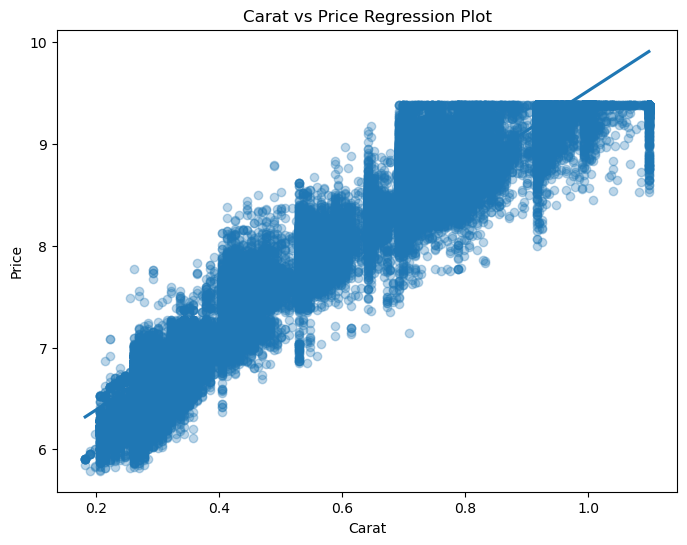

In [57]:
plt.figure(figsize=(8,6))

sns.regplot(x=data['carat'], y=data['price'], scatter_kws={'alpha':0.3})

plt.title("Carat vs Price Regression Plot")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.show()


Strong positive correlation: Price increases as carat weight increases.
Log-scaled price: The price axis is likely log-transformed, helping show the relationship more clearly.
Price ceiling: A horizontal line at the top indicates price clipping or maximum recorded price.
Carat clustering: Vertical stripes at values like 0.3, 0.5, 0.7 show diamonds are often cut at popular round carat weights.
Model deviation: At higher carat values, the regression line slightly overshoots, suggesting a simple linear model may not perfectly fit the upper range.

# Average price per cut, color, clarity using bar plots - Bivariate Analysis

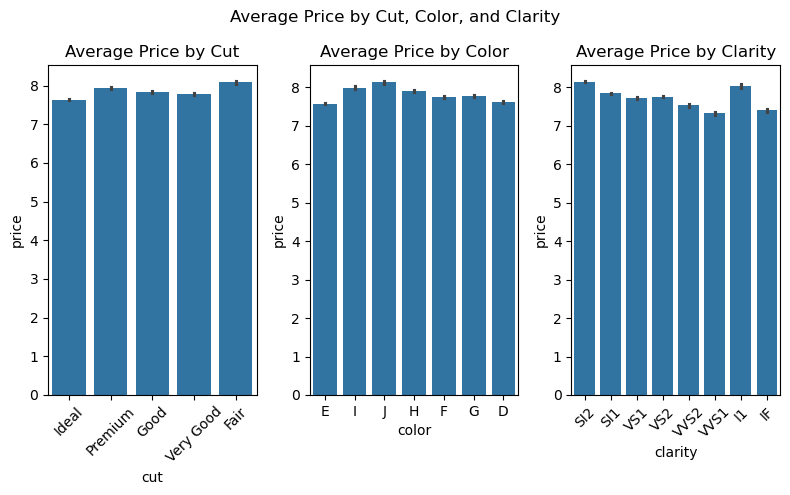

In [58]:
plt.figure(figsize=(8,5))
plt.suptitle("Average Price by Cut, Color, and Clarity")

# Average price by cut
plt.subplot(1,3,1)
sns.barplot(x='cut', y='price', data=data)
plt.xticks(rotation=45)
plt.title("Average Price by Cut")

# Average price by color
plt.subplot(1,3,2)
sns.barplot(x='color', y='price', data=data)
plt.title("Average Price by Color")

# Average price by clarity
plt.subplot(1,3,3)
sns.barplot(x='clarity', y='price', data=data)
plt.xticks(rotation=45)
plt.title("Average Price by Clarity")

plt.tight_layout()
plt.show()


Simpson’s Paradox: Lower-quality grades appear to have higher average prices because they usually have larger carat sizes.
Cut: Fair cut shows higher average price than Ideal due to larger diamond sizes.
Color: Lower grades like J and I appear more expensive on average because they include larger diamonds.
Clarity: Lower clarity grades (I1, SI2) show higher prices for the same reason.
Conclusion:
Carat (diamond size) is the main factor affecting price, which hides the real effect of cut, color, and clarity.

In [59]:
data.to_csv("cleaned_data.csv",index = False)